In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data_core_daily_v1.csv")

df["data"] = pd.to_datetime(df["data"])
df = df.sort_values(["CFGCENTROID", "data"])

print("Centros:", df["CFGCENTROID"].nunique())
print("Intervalo:", df["data"].min(), "→", df["data"].max())
print("Zeros atuais:", (df["y_inspecoes"] == 0).mean())

Centros: 51
Intervalo: 2022-01-03 00:00:00 → 2025-12-31 00:00:00
Zeros atuais: 0.0


In [3]:
def easter_sunday(year: int) -> pd.Timestamp:
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19*a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2*e + 2*i - h - k) % 7
    m = (a + 11*h + 22*l) // 451
    month = (h + l - 7*m + 114) // 31
    day = ((h + l - 7*m + 114) % 31) + 1
    return pd.Timestamp(year=year, month=month, day=day)

def pt_national_holidays(year):
    fixed = [
        (1,1),(4,25),(5,1),(6,10),
        (8,15),(10,5),(11,1),
        (12,1),(12,8),(12,25)
    ]
    easter = easter_sunday(year)
    movable = [
        easter - pd.Timedelta(days=2),
        easter + pd.Timedelta(days=60)
    ]
    out = {pd.Timestamp(year=year, month=m, day=d) for (m,d) in fixed}
    out |= set(movable)
    return out

years = df["data"].dt.year.unique()
holidays = set()
for y in years:
    holidays |= pt_national_holidays(int(y))

holidays = pd.DatetimeIndex(sorted(holidays))

In [4]:
centers = df["CFGCENTROID"].unique()
start, end = df["data"].min(), df["data"].max()

all_days = pd.date_range(start, end, freq="D")
all_days = all_days[all_days.dayofweek <= 5]

calendar = (
    pd.MultiIndex.from_product([centers, all_days],
                               names=["CFGCENTROID", "data"])
      .to_frame(index=False)
)

base = calendar.merge(
    df[["CFGCENTROID", "data", "y_inspecoes"]],
    on=["CFGCENTROID", "data"],
    how="left"
)

base["is_holiday"] = base["data"].isin(holidays).astype(int)
base["y_inspecoes"] = base["y_inspecoes"].fillna(0)

print("Zeros após reconstrução:", (base["y_inspecoes"] == 0).mean())

Zeros após reconstrução: 0.034450870676008216


In [5]:
base["dow"] = base["data"].dt.dayofweek
base["is_saturday"] = (base["dow"] == 5).astype(int)
base["week"] = base["data"].dt.isocalendar().week.astype(int)
base["month"] = base["data"].dt.month
base["year"] = base["data"].dt.year

In [6]:
base = base.sort_values(["CFGCENTROID", "data"])

for lag in [1, 7, 14, 28]:
    base[f"lag_{lag}"] = (
        base.groupby("CFGCENTROID")["y_inspecoes"]
        .shift(lag)
    )

base["roll7_mean"] = (
    base.groupby("CFGCENTROID")["y_inspecoes"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

base["roll28_mean"] = (
    base.groupby("CFGCENTROID")["y_inspecoes"]
    .shift(1)
    .rolling(28)
    .mean()
    .reset_index(level=0, drop=True)
)

df_model = base.dropna().copy()

In [7]:
cutoff = df_model["data"].max() - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= cutoff]
test  = df_model[df_model["data"] > cutoff]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (58344, 15)
Test: (4029, 15)


In [8]:
features = [
    "CFGCENTROID",
    "dow", "is_saturday", "week", "month", "year",
    "is_holiday",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll7_mean", "roll28_mean"
]

X_train = train[features]
y_train = train["y_inspecoes"]

X_test = test[features]
y_test = test["y_inspecoes"]

model = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
pred = np.clip(pred, 0, None)

# Forçar 0 em feriados
pred[test["is_holiday"] == 1] = 0

In [9]:
mae = np.mean(np.abs(y_test - pred))
wape_global = np.sum(np.abs(y_test - pred)) / np.sum(y_test)

print("MAE:", round(mae,3))
print("WAPE Global:", round(wape_global,4))

MAE: 12.897
WAPE Global: 0.1188


count    51.000000
mean      0.122677
std       0.020995
min       0.077360
25%       0.108906
50%       0.122265
75%       0.134425
max       0.183368
Name: WAPE, dtype: float64


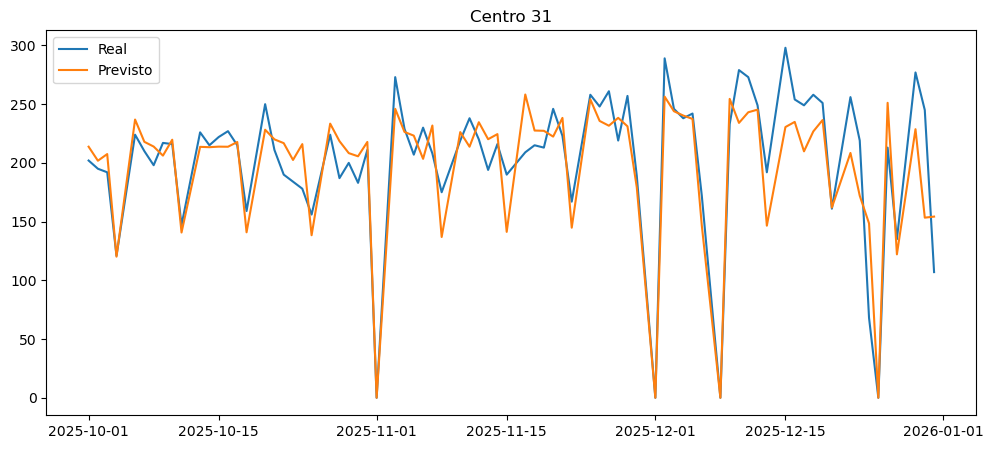

In [10]:
test_result = test.copy()
test_result["pred"] = pred
test_result["abs_err"] = np.abs(test_result["y_inspecoes"] - test_result["pred"])

wape_center = (
    test_result.groupby("CFGCENTROID")
    .agg(
        total_y=("y_inspecoes","sum"),
        total_err=("abs_err","sum")
    )
)

wape_center["WAPE"] = wape_center["total_err"] / wape_center["total_y"]

print(wape_center["WAPE"].describe())

center_big = (
    train.groupby("CFGCENTROID")["y_inspecoes"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

plot_df = test_result[test_result["CFGCENTROID"] == center_big]

plt.figure(figsize=(12,5))
plt.plot(plot_df["data"], plot_df["y_inspecoes"], label="Real")
plt.plot(plot_df["data"], plot_df["pred"], label="Previsto")
plt.title(f"Centro {center_big}")
plt.legend()
plt.show()

In [11]:
wape_center.sort_values("WAPE", ascending=False).head(10)

,total_y,total_err,WAPE
CFGCENTROID,,,
187,4639.0,850.645340,0.183368
188,4841.0,801.347101,0.165533
90,5109.0,837.529581,0.163932
57,6932.0,1123.058740,0.162011
4,4249.0,655.062593,0.154169
157,5914.0,868.059280,0.146780
32,5712.0,802.741456,0.140536
239,6364.0,894.178040,0.140506
176,6545.0,907.028112,0.138583


In [12]:
#PARTE 1 — Backtest Rolling (3 janelas móveis de 3 meses):

def train_evaluate(train_df, test_df, features):

    from sklearn.ensemble import HistGradientBoostingRegressor
    import numpy as np

    X_train = train_df[features]
    y_train = train_df["y_inspecoes"]

    X_test = test_df[features]
    y_test = test_df["y_inspecoes"]

    model = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = np.clip(pred, 0, None)

    # Forçar zero em feriados
    pred[test_df["is_holiday"] == 1] = 0

    mae = np.mean(np.abs(y_test - pred))
    wape = np.sum(np.abs(y_test - pred)) / np.sum(y_test)

    return mae, wape, pred

In [13]:
results = []

max_date = df_model["data"].max()

for i in range(3):

    test_end = max_date - pd.DateOffset(months=i)
    test_start = test_end - pd.DateOffset(months=3)

    train = df_model[df_model["data"] <= test_start]
    test  = df_model[(df_model["data"] > test_start) &
                     (df_model["data"] <= test_end)]

    mae, wape, pred = train_evaluate(train, test, features)

    results.append({
        "split": i+1,
        "test_start": test_start.date(),
        "test_end": test_end.date(),
        "MAE": mae,
        "WAPE": wape
    })

rolling_results = pd.DataFrame(results)
rolling_results

,split,test_start,test_end,MAE,WAPE
0,1,2025-09-30,2025-12-31,12.896549,0.118774
1,2,2025-08-30,2025-11-30,9.876659,0.094889
2,3,2025-07-31,2025-10-31,9.011254,0.094664


In [14]:
rolling_results.describe()

,split,MAE,WAPE
count,3.0,3.000000,3.000000
mean,2.0,10.594821,0.102776
std,1.0,2.039779,0.013855
min,1.0,9.011254,0.094664
25%,1.5,9.443956,0.094777
50%,2.0,9.876659,0.094889
75%,2.5,11.386604,0.106832
max,3.0,12.896549,0.118774


In [15]:
#📘 PARTE 2 — Segmentação por Volume de Centro:
center_volume = (
    df_model.groupby("CFGCENTROID")["y_inspecoes"]
    .mean()
    .reset_index()
    .rename(columns={"y_inspecoes": "mean_daily_volume"})
)

center_volume.head()


,CFGCENTROID,mean_daily_volume
0,4,51.270646
1,9,109.603434
2,10,93.048242
3,12,146.076043
4,13,102.457073


In [16]:
center_volume = (
    df_model.groupby("CFGCENTROID")["y_inspecoes"]
    .mean()
    .rename("mean_daily_volume")
    .reset_index()
)

q1, q2 = center_volume["mean_daily_volume"].quantile([0.33, 0.66]).values

center_volume["segmento"] = pd.cut(
    center_volume["mean_daily_volume"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Baixo Volume", "Volume Intermédio", "Alto Volume"]
)

center_volume["segmento"].value_counts()

segmento
Baixo Volume         17
Volume Intermédio    17
Alto Volume          17
Name: count, dtype: int64

In [17]:
# Recriar último split
test_end = df_model["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= test_start]
test  = df_model[(df_model["data"] > test_start)]

mae, wape, pred = train_evaluate(train, test, features)

test_result = test.copy()
test_result["pred"] = pred
test_result["abs_err"] = np.abs(test_result["y_inspecoes"] - test_result["pred"])

# Juntar segmento
test_result = test_result.merge(center_volume[["CFGCENTROID","segmento"]],
                                on="CFGCENTROID",
                                how="left")

segment_wape = (
    test_result.groupby("segmento")
    .agg(
        total_y=("y_inspecoes","sum"),
        total_err=("abs_err","sum")
    )
)

segment_wape["WAPE"] = segment_wape["total_err"] / segment_wape["total_y"]

segment_wape

/tmp/ipykernel_1355/652382142.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_result.groupby("segmento")


,total_y,total_err,WAPE
segmento,,,
Baixo Volume,102848.0,14285.569777,0.138900
Volume Intermédio,141970.0,16608.790767,0.116988
Alto Volume,192653.0,21065.835499,0.109346


In [18]:
#Comparação ridge, possion e hgo:
from sklearn.linear_model import Ridge, PoissonRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

def train_model(model_name, X_train, y_train):

    if model_name == "ridge":
        model = Ridge(alpha=1.0)

    elif model_name == "hgb":
        model = HistGradientBoostingRegressor(
            max_depth=6,
            learning_rate=0.05,
            max_iter=400,
            random_state=42
        )

    elif model_name == "poisson":
        model = PoissonRegressor(alpha=0.0, max_iter=1000)

    else:
        raise ValueError("Modelo desconhecido")

    model.fit(X_train, y_train)
    return model

In [19]:
models = ["ridge", "hgb", "poisson"]

comparison_results = []

max_date = df_model["data"].max()

for model_name in models:

    for i in range(3):

        test_end = max_date - pd.DateOffset(months=i)
        test_start = test_end - pd.DateOffset(months=3)

        train = df_model[df_model["data"] <= test_start]
        test  = df_model[(df_model["data"] > test_start) &
                         (df_model["data"] <= test_end)]

        X_train = train[features]
        y_train = train["y_inspecoes"]
        X_test  = test[features]
        y_test  = test["y_inspecoes"]

        model = train_model(model_name, X_train, y_train)

        pred = model.predict(X_test)
        pred = np.clip(pred, 0, None)
        pred[test["is_holiday"] == 1] = 0

        mae = np.mean(np.abs(y_test - pred))
        wape = np.sum(np.abs(y_test - pred)) / np.sum(y_test)

        comparison_results.append({
            "model": model_name,
            "split": i+1,
            "MAE": mae,
            "WAPE": wape
        })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


,model,split,MAE,WAPE
0,ridge,1,15.752312,0.145075
1,ridge,2,11.824699,0.113605
2,ridge,3,12.131824,0.127446
3,hgb,1,12.896549,0.118774
4,hgb,2,9.876659,0.094889
5,hgb,3,9.011254,0.094664
6,poisson,1,33.520877,0.308719
7,poisson,2,30.952493,0.297373
8,poisson,3,30.704494,0.322554


In [20]:
comparison_df.groupby("model")[["MAE", "WAPE"]].mean().sort_values("WAPE")

,MAE,WAPE
model,,
hgb,10.594821,0.102776
ridge,13.236278,0.128708
poisson,31.725955,0.309549


In [21]:
# Baseline Mean by Day of Week:
def mean_by_dow_baseline(train, test):

    # média por centro e dia da semana
    mean_table = (
        train.groupby(["CFGCENTROID", "dow"])["y_inspecoes"]
        .mean()
        .reset_index()
        .rename(columns={"y_inspecoes": "mean_dow"})
    )

    test_baseline = test.merge(mean_table,
                               on=["CFGCENTROID", "dow"],
                               how="left")

    pred = test_baseline["mean_dow"].values
    pred[test_baseline["is_holiday"] == 1] = 0

    mae = np.mean(np.abs(test["y_inspecoes"] - pred))
    wape = np.sum(np.abs(test["y_inspecoes"] - pred)) / np.sum(test["y_inspecoes"])

    return mae, wape

In [22]:
# split final
test_end = df_model["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= test_start]
test  = df_model[df_model["data"] > test_start]

# HGB
mae_hgb, wape_hgb, pred_hgb = train_evaluate(train, test, features)

# Baseline
mae_base, wape_base = mean_by_dow_baseline(train, test)

print("Baseline MAE:", round(mae_base,2))
print("Baseline WAPE:", round(wape_base,4))
print("HGB MAE:", round(mae_hgb,2))
print("HGB WAPE:", round(wape_hgb,4))

Baseline MAE: 17.12
Baseline WAPE: 0.1576
HGB MAE: 12.9
HGB WAPE: 0.1188


In [23]:
# Split final (últimos 3 meses)
test_end = df_model["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= test_start]
test  = df_model[df_model["data"] > test_start]

X_train = train[features]
y_train = train["y_inspecoes"]

X_test = test[features]
y_test = test["y_inspecoes"]

from sklearn.ensemble import HistGradientBoostingRegressor

model_hgb = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

model_hgb.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,400
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [24]:
#Gráfico Real vs Previsto + Diferença:
center_median = (
    center_volume.sort_values("mean_daily_volume")
    .iloc[len(center_volume)//2]["CFGCENTROID"]
)

center_median

178

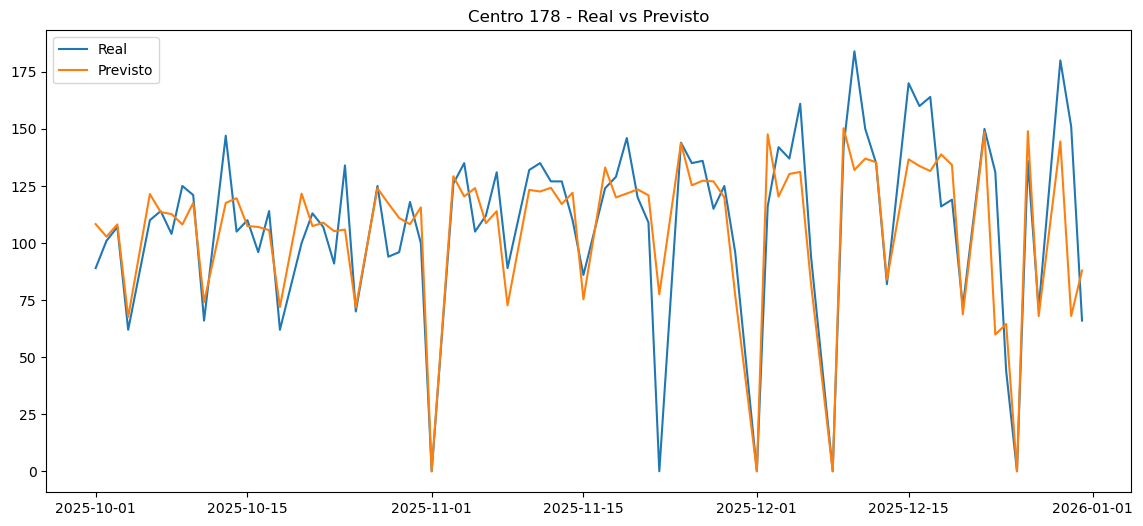

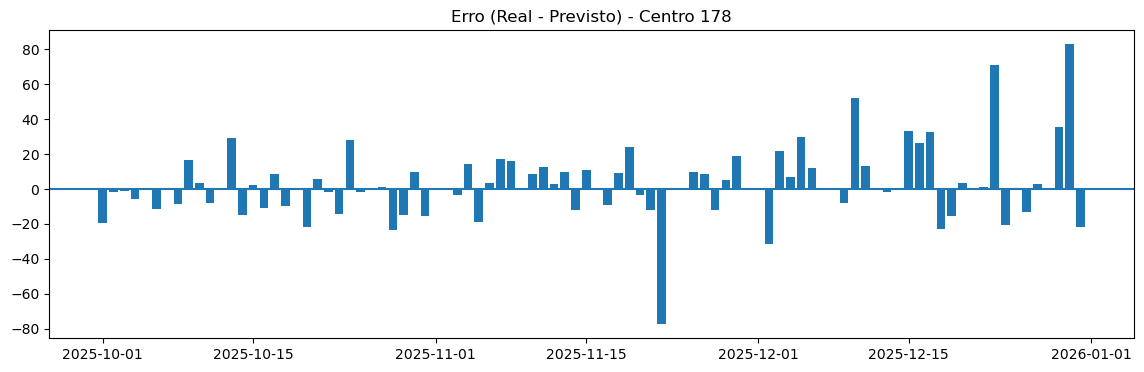

In [25]:
plot_df = test.copy()
plot_df["pred"] = pred_hgb
plot_df = plot_df[plot_df["CFGCENTROID"] == center_median]

plot_df["erro"] = plot_df["y_inspecoes"] - plot_df["pred"]

plt.figure(figsize=(14,6))
plt.plot(plot_df["data"], plot_df["y_inspecoes"], label="Real")
plt.plot(plot_df["data"], plot_df["pred"], label="Previsto")
plt.title(f"Centro {center_median} - Real vs Previsto")
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.bar(plot_df["data"], plot_df["erro"])
plt.title(f"Erro (Real - Previsto) - Centro {center_median}")
plt.axhline(0)
plt.show()

In [26]:
base = base.sort_values(["CFGCENTROID", "data"])

# índice temporal contínuo
base["time_idx"] = (base["data"] - base["data"].min()).dt.days

# novos lags
for lag in [2, 3]:
    base[f"lag_{lag}"] = (
        base.groupby("CFGCENTROID")["y_inspecoes"]
        .shift(lag)
    )

# rolling mediana
base["roll7_median"] = (
    base.groupby("CFGCENTROID")["y_inspecoes"]
    .shift(1)
    .rolling(7)
    .median()
    .reset_index(level=0, drop=True)
)

df_model = base.dropna().copy()

In [27]:
features_refined = [
    "CFGCENTROID",
    "dow",
    "month",
    "is_saturday",
    "is_holiday",
    "time_idx",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll7_mean",
    "roll28_mean"
]

In [28]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

# Garantir que time_idx existe
df_model = df_model.copy()
df_model["time_idx"] = (df_model["data"] - df_model["data"].min()).dt.days

features_refined = [
    "CFGCENTROID",
    "dow",
    "month",
    "is_saturday",
    "is_holiday",
    "time_idx",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll7_mean",
    "roll28_mean",
]

# Split final: últimos 3 meses
test_end = df_model["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= test_start]
test  = df_model[df_model["data"] > test_start]

X_train = train[features_refined]
y_train = train["y_inspecoes"]

X_test = test[features_refined]
y_test = test["y_inspecoes"]

model_refined = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

# FIT (faltava isto)
model_refined.fit(X_train, y_train)

pred_refined = model_refined.predict(X_test)
pred_refined = np.clip(pred_refined, 0, None)
pred_refined[test["is_holiday"] == 1] = 0

mae_refined = np.mean(np.abs(y_test - pred_refined))
wape_refined = np.sum(np.abs(y_test - pred_refined)) / np.sum(y_test)

print("MAE refined:", round(mae_refined, 3))
print("WAPE refined:", round(wape_refined, 4))

MAE refined: 16.121
WAPE refined: 0.1485


In [29]:
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
import itertools

param_grid = {
    "max_depth": [5,6,7],
    "learning_rate": [0.03, 0.05],
    "max_iter": [300,400,500]
}

results_grid = []

for md, lr, mi in itertools.product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["max_iter"]):
    
    model = HistGradientBoostingRegressor(
        max_depth=md,
        learning_rate=lr,
        max_iter=mi,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = np.clip(pred, 0, None)
    pred[test["is_holiday"] == 1] = 0
    
    wape = np.sum(np.abs(y_test - pred)) / np.sum(y_test)
    
    results_grid.append({
        "max_depth": md,
        "learning_rate": lr,
        "max_iter": mi,
        "WAPE": wape
    })

grid_df = pd.DataFrame(results_grid).sort_values("WAPE")
grid_df.head(10)

,max_depth,learning_rate,max_iter,WAPE
0,5,0.03,300,0.121705
1,5,0.03,400,0.124839
2,5,0.03,500,0.127988
12,7,0.03,300,0.128913
13,7,0.03,400,0.131297
6,6,0.03,300,0.133976
7,6,0.03,400,0.134272
14,7,0.03,500,0.135860
3,5,0.05,300,0.136321
4,5,0.05,400,0.136824


In [30]:
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

def train_per_center(df_model, features):

    test_end = df_model["data"].max()
    test_start = test_end - pd.DateOffset(months=3)

    train_all = df_model[df_model["data"] <= test_start]
    test_all  = df_model[df_model["data"] > test_start]

    results = []

    for center in df_model["CFGCENTROID"].unique():

        train = train_all[train_all["CFGCENTROID"] == center]
        test  = test_all[test_all["CFGCENTROID"] == center]

        if len(test) == 0 or len(train) < 200:
            continue

        X_train = train[features]
        y_train = train["y_inspecoes"]

        X_test = test[features]
        y_test = test["y_inspecoes"]

        model = HistGradientBoostingRegressor(
            max_depth=6,
            learning_rate=0.05,
            max_iter=400,
            random_state=42
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        pred = np.clip(pred, 0, None)
        pred[test["is_holiday"] == 1] = 0

        total_y = np.sum(y_test)
        total_err = np.sum(np.abs(y_test - pred))

        results.append({
            "CFGCENTROID": center,
            "total_y": total_y,
            "total_err": total_err,
            "WAPE": total_err / total_y
        })

    results_df = pd.DataFrame(results)

    wape_global = results_df["total_err"].sum() / results_df["total_y"].sum()

    return results_df, wape_global

In [31]:
results_center, wape_center_model = train_per_center(df_model, features)

print("WAPE modelo por centro:", round(wape_center_model,4))
results_center["WAPE"].describe()

WAPE modelo por centro: 0.1211


count    51.000000
mean      0.125489
std       0.021415
min       0.080940
25%       0.112880
50%       0.124542
75%       0.134456
max       0.177581
Name: WAPE, dtype: float64